# Clustering

In [44]:
import pandas as pd
import numpy as np
import sys
sys.path.insert(0, '../modules')
from preprocessing import process_data

In [45]:
# Set random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
import random
random.seed(RANDOM_SEED)

In [46]:
# Load and process test data
train_df_raw = pd.read_csv('../data/train_data.csv')

# Remove leading/trailing spaces from column names
train_df_raw.columns = train_df_raw.columns.str.strip()

print("Raw train data loaded:")
print(f"Shape: {train_df_raw.shape}")
print(f"Columns: {len(train_df_raw.columns)}")

Raw train data loaded:
Shape: (5807, 97)
Columns: 97


In [47]:
# Process test data using our function
train_df_processed = process_data(train_df_raw, artifacts_path='../EDA/preprocessing_artifacts.pkl')

print(f"\n{'='*70}")
print("Train data after processing:")
print(f"Shape: {train_df_processed.shape}")
print(f"Columns: {len(train_df_processed.columns)}")

Preserved 'Bankrupt?' column
Dropped 54 columns not in training features
Scaled 14 non-normalized features

Train data after processing:
Shape: (5807, 43)
Columns: 43


In [48]:
train_df_processed.head()

,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Expense Rate,Research and development expense rate,Interest-bearing debt interest rate,Tax rate (A),Net Value Per Share (B),Net Value Per Share (A),Net Value Per Share (C),...,Cash Turnover Rate,Current Liability to Liability,Cash Flow to Total Assets,CFO to Assets,Current Liability to Current Assets,Liability-Assets Flag,Net Income to Total Assets,Total assets to GNP price,Equity to Liability,Bankrupt?
0,0.450397,0.504034,0.506986,8.018018e-01,0.000000,4.182232e-13,0.000000,0.178754,0.178754,0.178754,...,5.450000e-01,0.403584,0.666103,0.570385,0.029919,0,0.780554,4.906065e-13,0.032464,0
1,0.530005,0.572885,0.574763,1.025566e-14,0.027255,1.414283e-13,0.259439,0.200413,0.200413,0.200413,...,4.450000e-01,0.824851,0.654556,0.595348,0.025790,0,0.819963,5.973599e-13,0.032442,0
2,0.571150,0.620148,0.624177,1.060290e-14,0.424850,2.626525e-13,0.104464,0.203278,0.203278,0.203278,...,1.345160e-14,0.523066,0.691773,0.631543,0.018529,0,0.839128,6.029052e-13,0.033034,0
3,0.483401,0.556694,0.536164,7.537538e-01,0.000000,2.707343e-13,0.000000,0.179217,0.179217,0.179217,...,6.160000e-01,0.839147,0.654096,0.404612,0.034617,0,0.806477,2.113446e-13,0.015406,0
4,0.510359,0.537287,0.552546,6.276276e-01,0.236473,4.131727e-13,0.732058,0.194766,0.194766,0.194766,...,9.810000e-02,0.914601,0.618000,0.573564,0.031509,0,0.799277,1.041251e-13,0.028858,0


In [49]:
train_df_processed.describe()

,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Expense Rate,Research and development expense rate,Interest-bearing debt interest rate,Tax rate (A),Net Value Per Share (B),Net Value Per Share (A),Net Value Per Share (C),...,Cash Turnover Rate,Current Liability to Liability,Cash Flow to Total Assets,CFO to Assets,Current Liability to Current Assets,Liability-Assets Flag,Net Income to Total Assets,Total assets to GNP price,Equity to Liability,Bankrupt?
count,5807.000000,5807.000000,5807.000000,5.807000e+03,5.807000e+03,5.807000e+03,5807.000000,5807.000000,5807.000000,5807.000000,...,5.807000e+03,5807.000000,5807.000000,5807.000000,5807.000000,5807.000000,5807.000000,5.807000e+03,5807.000000,5807.000000
mean,0.505416,0.558893,0.553852,1.999255e-01,1.987639e-01,1.628373e-02,0.115361,0.190924,0.190892,0.190936,...,2.487315e-01,0.760572,0.650121,0.593523,0.031634,0.001205,0.807956,1.836571e-03,0.047736,0.034097
std,0.060808,0.065650,0.061613,3.241629e-01,2.619362e-01,1.081248e-01,0.139756,0.033914,0.034009,0.034016,...,2.963376e-01,0.206844,0.046249,0.057913,0.031840,0.034702,0.039062,3.773944e-02,0.049046,0.181493
min,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000e+00,0.000000,0.167678,0.074249,0.000000,0.000000,0.224792,0.000000e+00,0.000000,0.000000
25%,0.476673,0.535679,0.527437,1.560921e-14,1.301463e-14,2.045657e-13,0.000000,0.173739,0.173739,0.173760,...,2.738165e-14,0.624938,0.633468,0.566223,0.018037,0.000000,0.796843,8.169537e-14,0.024395,0.000000
50%,0.503096,0.559911,0.552492,2.775736e-14,5.440882e-02,3.232646e-13,0.073692,0.184484,0.184484,0.184569,...,1.050000e-01,0.805698,0.645430,0.592746,0.027636,0.000000,0.810710,2.043571e-13,0.033687,0.000000
75%,0.535417,0.589212,0.583998,4.194194e-01,3.517034e-01,5.343970e-13,0.205385,0.199865,0.199928,0.200034,...,4.550000e-01,0.941624,0.663480,0.624780,0.038440,0.000000,0.826544,5.323033e-13,0.053393,0.000000
max,1.000000,1.000000,1.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000,1.000000,1.000000,1.000000,...,1.000000e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000e+00,0.920638,1.000000


In [50]:
attributes = train_df_processed.drop(columns=["Bankrupt?"])
attributes.shape

(5807, 42)

In [51]:
attributes.head()

,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Expense Rate,Research and development expense rate,Interest-bearing debt interest rate,Tax rate (A),Net Value Per Share (B),Net Value Per Share (A),Net Value Per Share (C),...,Quick Asset Turnover Rate,Cash Turnover Rate,Current Liability to Liability,Cash Flow to Total Assets,CFO to Assets,Current Liability to Current Assets,Liability-Assets Flag,Net Income to Total Assets,Total assets to GNP price,Equity to Liability
0,0.450397,0.504034,0.506986,8.018018e-01,0.000000,4.182232e-13,0.000000,0.178754,0.178754,0.178754,...,3.880000e-01,5.450000e-01,0.403584,0.666103,0.570385,0.029919,0,0.780554,4.906065e-13,0.032464
1,0.530005,0.572885,0.574763,1.025566e-14,0.027255,1.414283e-13,0.259439,0.200413,0.200413,0.200413,...,1.992600e-15,4.450000e-01,0.824851,0.654556,0.595348,0.025790,0,0.819963,5.973599e-13,0.032442
2,0.571150,0.620148,0.624177,1.060290e-14,0.424850,2.626525e-13,0.104464,0.203278,0.203278,0.203278,...,5.723600e-15,1.345160e-14,0.523066,0.691773,0.631543,0.018529,0,0.839128,6.029052e-13,0.033034
3,0.483401,0.556694,0.536164,7.537538e-01,0.000000,2.707343e-13,0.000000,0.179217,0.179217,0.179217,...,2.660000e-01,6.160000e-01,0.839147,0.654096,0.404612,0.034617,0,0.806477,2.113446e-13,0.015406
4,0.510359,0.537287,0.552546,6.276276e-01,0.236473,4.131727e-13,0.732058,0.194766,0.194766,0.194766,...,7.560000e-01,9.810000e-02,0.914601,0.618000,0.573564,0.031509,0,0.799277,1.041251e-13,0.028858


# K-means Clustering

Using preprocessed data with shape: (5807, 42)
Data range: min=0.0000, max=1.0000
K=2: Inertia = 5002.9964
K=3: Inertia = 4570.5321
K=4: Inertia = 4229.8594
K=5: Inertia = 3960.7964
K=6: Inertia = 3703.7663
K=7: Inertia = 3528.6394
K=8: Inertia = 3389.1937
K=9: Inertia = 3278.7540
K=10: Inertia = 3178.4045


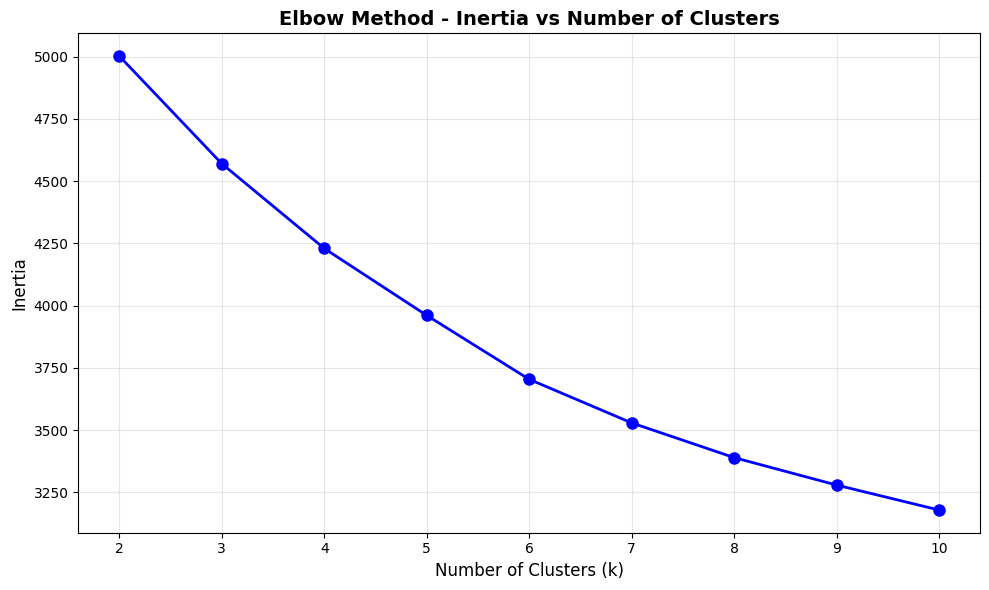

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Data is already scaled during preprocessing
print(f"Using preprocessed data with shape: {attributes.shape}")
print(f"Data range: min={attributes.min().min():.4f}, max={attributes.max().max():.4f}")

# Implement K-means with different k values
k_values = range(2, 11)
inertias = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10)
    kmeans.fit(attributes.values)
    inertias.append(kmeans.inertia_)
    print(f"K={k}: Inertia = {kmeans.inertia_:.4f}")

# Plot inertia versus k (Elbow method)
plt.figure(figsize=(10, 6))
plt.plot(k_values, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia', fontsize=12)
plt.title('Elbow Method - Inertia vs Number of Clusters', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(k_values)
plt.tight_layout()
plt.show()

We will choose the elbow at k = 8

In [53]:
optimal_k = 8

In [54]:
# Fit K-means with optimal k
final_kmeans = KMeans(n_clusters=optimal_k, random_state=RANDOM_SEED, n_init=10)
cluster_labels = final_kmeans.fit_predict(attributes.values)

# Create a dataframe with cluster labels and bankruptcy status
clustering_results = pd.DataFrame({
    'Cluster': cluster_labels,
    'Bankrupt?': train_df_processed['Bankrupt?'].values
})

# Analyze each cluster
print(f"{'='*70}")
print(f"Cluster Analysis (k={optimal_k})")
print(f"{'='*70}\n")

cluster_stats = []

for cluster in range(optimal_k):
    cluster_data = clustering_results[clustering_results['Cluster'] == cluster]
    total_samples = len(cluster_data)
    bankrupt_count = (cluster_data['Bankrupt?'] == 1).sum()
    non_bankrupt_count = total_samples - bankrupt_count
    bankrupt_pct = (bankrupt_count / total_samples) * 100
    
    cluster_stats.append({
        'Cluster': cluster,
        'Total Samples': total_samples,
        'Bankrupt (1)': bankrupt_count,
        'Non-Bankrupt (0)': non_bankrupt_count,
        'Bankrupt %': f"{bankrupt_pct:.2f}%"
    })
    
    print(f"Cluster {cluster}:")
    print(f"  Total samples: {total_samples}")
    print(f"  Bankrupt (1): {bankrupt_count}")
    print(f"  Non-Bankrupt (0): {non_bankrupt_count}")
    print(f"  Bankruptcy rate: {bankrupt_pct:.2f}%\n")

# Create a summary dataframe
stats_df = pd.DataFrame(cluster_stats)
print(f"{'='*70}")
print("Summary Table:")
print(f"{'='*70}")
print(stats_df.to_string(index=False))

print(f"\n{'='*70}")
print(f"Total samples: {len(clustering_results)}")
total_bankrupt = (train_df_processed['Bankrupt?'] == 1).sum()
print(f"Overall bankruptcy count: {total_bankrupt}")
print(f"Overall bankruptcy rate: {(total_bankrupt/len(clustering_results))*100:.2f}%")

Cluster Analysis (k=8)

Cluster 0:
  Total samples: 571
  Bankrupt (1): 13
  Non-Bankrupt (0): 558
  Bankruptcy rate: 2.28%

Cluster 1:
  Total samples: 788
  Bankrupt (1): 32
  Non-Bankrupt (0): 756
  Bankruptcy rate: 4.06%

Cluster 2:
  Total samples: 680
  Bankrupt (1): 23
  Non-Bankrupt (0): 657
  Bankruptcy rate: 3.38%

Cluster 3:
  Total samples: 742
  Bankrupt (1): 48
  Non-Bankrupt (0): 694
  Bankruptcy rate: 6.47%

Cluster 4:
  Total samples: 772
  Bankrupt (1): 29
  Non-Bankrupt (0): 743
  Bankruptcy rate: 3.76%

Cluster 5:
  Total samples: 929
  Bankrupt (1): 24
  Non-Bankrupt (0): 905
  Bankruptcy rate: 2.58%

Cluster 6:
  Total samples: 627
  Bankrupt (1): 13
  Non-Bankrupt (0): 614
  Bankruptcy rate: 2.07%

Cluster 7:
  Total samples: 698
  Bankrupt (1): 16
  Non-Bankrupt (0): 682
  Bankruptcy rate: 2.29%

Summary Table:
 Cluster  Total Samples  Bankrupt (1)  Non-Bankrupt (0) Bankrupt %
       0            571            13               558      2.28%
       1           

# Gaussian Mixture Model (GMM) Clustering

Gaussian Mixture Model (GMM) Clustering
Components=2: BIC = -1237802.98, AIC = -1250409.93
Components=3: BIC = -1350220.72, AIC = -1369134.48
Components=4: BIC = -1404567.41, AIC = -1429787.99
Components=5: BIC = -1405594.49, AIC = -1437121.88
Components=6: BIC = -1436648.12, AIC = -1474482.32
Components=7: BIC = -1449532.57, AIC = -1493673.58
Components=8: BIC = -1471473.19, AIC = -1521921.01
Components=9: BIC = -1471249.75, AIC = -1528004.38
Components=10: BIC = -1472220.64, AIC = -1535282.09


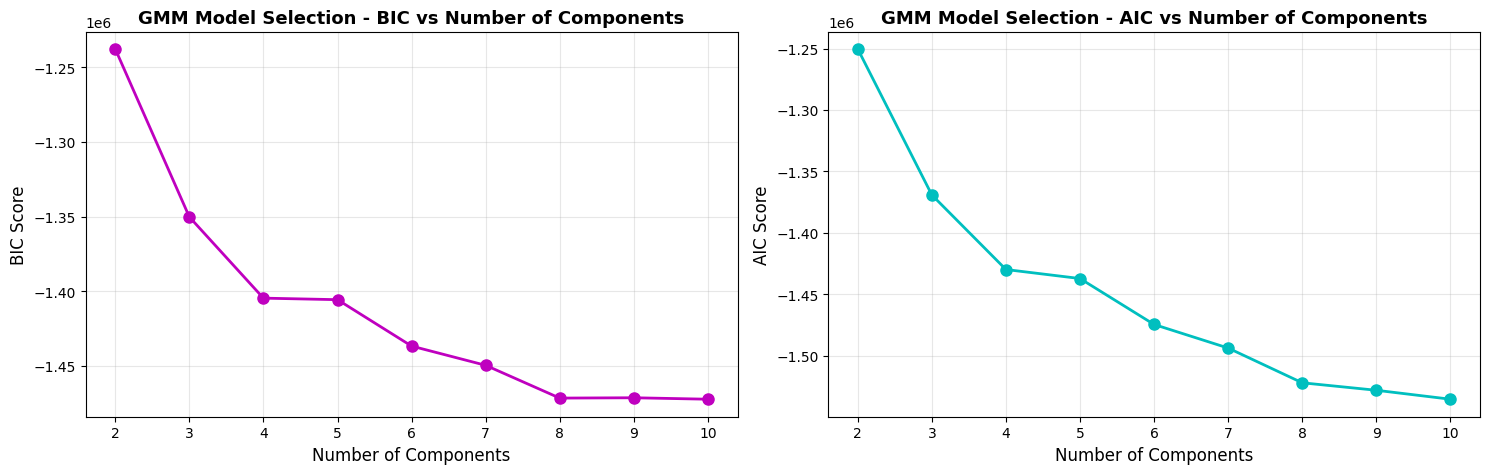


GMM Elbow Analysis Complete
Lower BIC/AIC indicates better fit (optimal balance between model fit and complexity)
Note: GMM uses BIC/AIC for model selection, not inertia like K-means


In [55]:
from sklearn.mixture import GaussianMixture

# Implement Gaussian Mixture Model with different numbers of components
print("Gaussian Mixture Model (GMM) Clustering")
print(f"{'='*70}")

n_components_range = range(2, 11)
bic_scores = []
aic_scores = []
neg_log_likelihood = []

for n_components in n_components_range:
    gmm = GaussianMixture(n_components=n_components, random_state=RANDOM_SEED, n_init=10)
    gmm.fit(attributes.values)
    bic_scores.append(gmm.bic(attributes.values))
    aic_scores.append(gmm.aic(attributes.values))
    neg_log_likelihood.append(-gmm.score(attributes.values) * len(attributes))
    print(f"Components={n_components}: BIC = {bic_scores[-1]:.2f}, AIC = {aic_scores[-1]:.2f}")

# Plot BIC and AIC for model selection (Elbow method for GMM)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# BIC plot
ax1.plot(n_components_range, bic_scores, 'mo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Components', fontsize=12)
ax1.set_ylabel('BIC Score', fontsize=12)
ax1.set_title('GMM Model Selection - BIC vs Number of Components', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(n_components_range)

# AIC plot
ax2.plot(n_components_range, aic_scores, 'co-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Components', fontsize=12)
ax2.set_ylabel('AIC Score', fontsize=12)
ax2.set_title('GMM Model Selection - AIC vs Number of Components', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(n_components_range)

plt.tight_layout()
plt.show()

print(f"\n{'='*70}")
print("GMM Elbow Analysis Complete")
print(f"Lower BIC/AIC indicates better fit (optimal balance between model fit and complexity)")
print(f"Note: GMM uses BIC/AIC for model selection, not inertia like K-means")

# GMM Cluster Analysis (8 Components)

In [56]:
# Fit GMM with 8 components for comparison with K-means
optimal_components_gmm = 8
gmm_final = GaussianMixture(n_components=optimal_components_gmm, random_state=RANDOM_SEED, n_init=10)
gmm_cluster_labels = gmm_final.fit_predict(attributes.values)

# Get soft assignments (probabilities)
gmm_probabilities = gmm_final.predict_proba(attributes.values)

# Create a dataframe with cluster labels and bankruptcy status
gmm_clustering_results = pd.DataFrame({
    'Component': gmm_cluster_labels,
    'Bankrupt?': train_df_processed['Bankrupt?'].values
})

# Analyze each component
print(f"{'='*70}")
print(f"GMM Cluster Analysis (components={optimal_components_gmm})")
print(f"{'='*70}\n")

gmm_cluster_stats = []

for component in range(optimal_components_gmm):
    component_data = gmm_clustering_results[gmm_clustering_results['Component'] == component]
    total_samples = len(component_data)
    bankrupt_count = (component_data['Bankrupt?'] == 1).sum()
    non_bankrupt_count = total_samples - bankrupt_count
    bankrupt_pct = (bankrupt_count / total_samples) * 100
    
    gmm_cluster_stats.append({
        'Component': component,
        'Total Samples': total_samples,
        'Bankrupt (1)': bankrupt_count,
        'Non-Bankrupt (0)': non_bankrupt_count,
        'Bankrupt %': f"{bankrupt_pct:.2f}%"
    })
    
    print(f"Component {component}:")
    print(f"  Total samples: {total_samples}")
    print(f"  Bankrupt (1): {bankrupt_count}")
    print(f"  Non-Bankrupt (0): {non_bankrupt_count}")
    print(f"  Bankruptcy rate: {bankrupt_pct:.2f}%\n")

# Create a summary dataframe
gmm_stats_df = pd.DataFrame(gmm_cluster_stats)
print(f"{'='*70}")
print("Summary Table:")
print(f"{'='*70}")
print(gmm_stats_df.to_string(index=False))

print(f"\n{'='*70}")
print(f"Total samples: {len(gmm_clustering_results)}")
total_bankrupt = (train_df_processed['Bankrupt?'] == 1).sum()
print(f"Overall bankruptcy count: {total_bankrupt}")
print(f"Overall bankruptcy rate: {(total_bankrupt/len(gmm_clustering_results))*100:.2f}%")

print(f"\n{'='*70}")
print("GMM vs K-means Comparison:")
print(f"{'='*70}")
print(f"K-means: Highest bankruptcy rate = Cluster 3 (6.47%)")
print(f"GMM: Highest bankruptcy rate = Component {gmm_stats_df.loc[gmm_stats_df['Bankrupt %'].str.rstrip('%').astype(float).idxmax(), 'Component']} ({gmm_stats_df['Bankrupt %'].iloc[gmm_stats_df['Bankrupt %'].str.rstrip('%').astype(float).idxmax()]})")
print(f"K-means: Lowest bankruptcy rate = Cluster 6 (2.07%)")
print(f"GMM: Lowest bankruptcy rate = Component {gmm_stats_df.loc[gmm_stats_df['Bankrupt %'].str.rstrip('%').astype(float).idxmin(), 'Component']} ({gmm_stats_df['Bankrupt %'].iloc[gmm_stats_df['Bankrupt %'].str.rstrip('%').astype(float).idxmin()]})")

GMM Cluster Analysis (components=8)

Component 0:
  Total samples: 937
  Bankrupt (1): 26
  Non-Bankrupt (0): 911
  Bankruptcy rate: 2.77%

Component 1:
  Total samples: 351
  Bankrupt (1): 40
  Non-Bankrupt (0): 311
  Bankruptcy rate: 11.40%

Component 2:
  Total samples: 901
  Bankrupt (1): 16
  Non-Bankrupt (0): 885
  Bankruptcy rate: 1.78%

Component 3:
  Total samples: 935
  Bankrupt (1): 41
  Non-Bankrupt (0): 894
  Bankruptcy rate: 4.39%

Component 4:
  Total samples: 976
  Bankrupt (1): 15
  Non-Bankrupt (0): 961
  Bankruptcy rate: 1.54%

Component 5:
  Total samples: 172
  Bankrupt (1): 5
  Non-Bankrupt (0): 167
  Bankruptcy rate: 2.91%

Component 6:
  Total samples: 178
  Bankrupt (1): 23
  Non-Bankrupt (0): 155
  Bankruptcy rate: 12.92%

Component 7:
  Total samples: 1357
  Bankrupt (1): 32
  Non-Bankrupt (0): 1325
  Bankruptcy rate: 2.36%

Summary Table:
 Component  Total Samples  Bankrupt (1)  Non-Bankrupt (0) Bankrupt %
         0            937            26             

# Clustering Comparison: K-means vs GMM

In [60]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, normalized_mutual_info_score
import warnings
warnings.filterwarnings('ignore')

print(f"{'='*80}")
print("COMPREHENSIVE CLUSTERING EVALUATION")
print(f"{'='*80}\n")

# Get the true labels
true_labels = train_df_processed['Bankrupt?'].values

# 1. Silhouette Score (higher is better, range -1 to 1)
print("1. SILHOUETTE SCORE (higher is better, range: -1 to 1). Measures how similar samples are to their own cluster vs. other clusters")
print("-" * 80)
silhouette_kmeans = silhouette_score(attributes.values, cluster_labels)
silhouette_gmm = silhouette_score(attributes.values, gmm_cluster_labels)
print(f"K-means (k=8):        {silhouette_kmeans:.4f}")
print(f"GMM (components=8):   {silhouette_gmm:.4f}")
print(f"Winner: {'K-means' if silhouette_kmeans > silhouette_gmm else 'GMM'} (+{abs(silhouette_kmeans - silhouette_gmm):.4f})")

# 2. Davies-Bouldin Index (lower is better)
print(f"\n2. DAVIES-BOULDIN INDEX (lower is better). Measures average similarity between clusters")
print("-" * 80)
davies_bouldin_kmeans = davies_bouldin_score(attributes.values, cluster_labels)
davies_bouldin_gmm = davies_bouldin_score(attributes.values, gmm_cluster_labels)
print(f"K-means (k=8):        {davies_bouldin_kmeans:.4f}")
print(f"GMM (components=8):   {davies_bouldin_gmm:.4f}")
print(f"Winner: {'K-means' if davies_bouldin_kmeans < davies_bouldin_gmm else 'GMM'}")

# 3. Calinski-Harabasz Index (higher is better)
print(f"\n3. CALINSKI-HARABASZ INDEX (higher is better). Ratio of between-cluster to within-cluster distances")
print("-" * 80)
calinski_kmeans = calinski_harabasz_score(attributes.values, cluster_labels)
calinski_gmm = calinski_harabasz_score(attributes.values, gmm_cluster_labels)
print(f"K-means (k=8):        {calinski_kmeans:.2f}")
print(f"GMM (components=8):   {calinski_gmm:.2f}")
print(f"Winner: {'K-means' if calinski_kmeans > calinski_gmm else 'GMM'}")

# 4. Normalized Mutual Information (higher is better, measures alignment with true labels)
print(f"\n4. NORMALIZED MUTUAL INFORMATION (higher is better). How much information clustering has about bankruptcy")
print("-" * 80)
nmi_kmeans = normalized_mutual_info_score(true_labels, cluster_labels)
nmi_gmm = normalized_mutual_info_score(true_labels, gmm_cluster_labels)
print(f"K-means (k=8):        {nmi_kmeans:.4f}")
print(f"GMM (components=8):   {nmi_gmm:.4f}")
print(f"Winner: {'K-means' if nmi_kmeans > nmi_gmm else 'GMM'}")
print(f"\nInterpretation: How well does the clustering align with bankruptcy labels?")

# 5. Bankruptcy Risk Separation
print(f"\n5. BANKRUPTCY RISK STRATIFICATION")
print("-" * 80)

# Extract bankruptcy percentages
kmeans_bankruptcy_rates = [float(x.rstrip('%')) for x in stats_df['Bankrupt %']]
gmm_bankruptcy_rates = [float(x.rstrip('%')) for x in gmm_stats_df['Bankrupt %']]

kmeans_spread = max(kmeans_bankruptcy_rates) - min(kmeans_bankruptcy_rates)
gmm_spread = max(gmm_bankruptcy_rates) - min(gmm_bankruptcy_rates)

print(f"K-means bankruptcy rate range:  {min(kmeans_bankruptcy_rates):.2f}% - {max(kmeans_bankruptcy_rates):.2f}%")
print(f"GMM bankruptcy rate range:      {min(gmm_bankruptcy_rates):.2f}% - {max(gmm_bankruptcy_rates):.2f}%")
print(f"K-means spread (max - min):     {kmeans_spread:.2f}%")
print(f"GMM spread (max - min):         {gmm_spread:.2f}%")
print(f"Winner: {'K-means' if kmeans_spread > gmm_spread else 'GMM'} (better risk stratification)")

# Summary table
print(f"\n{'='*80}")
print("SUMMARY SCORECARD")
print(f"{'='*80}\n")

comparison_df = pd.DataFrame({
    'Metric': [
        'Silhouette Score',
        'Davies-Bouldin Index',
        'Calinski-Harabasz Index',
        'Normalized Mutual Info',
        'Bankruptcy Separation'
    ],
    'K-means': [
        f"{silhouette_kmeans:.4f}",
        f"{davies_bouldin_kmeans:.4f}",
        f"{calinski_kmeans:.2f}",
        f"{nmi_kmeans:.4f}",
        f"{kmeans_spread:.2f}%"
    ],
    'GMM': [
        f"{silhouette_gmm:.4f}",
        f"{davies_bouldin_gmm:.4f}",
        f"{calinski_gmm:.2f}",
        f"{nmi_gmm:.4f}",
        f"{gmm_spread:.2f}%"
    ],
    'Better (Higher/Lower)': [
        'Higher',
        'Lower',
        'Higher',
        'Higher',
        'Higher'
    ]
})

print(comparison_df.to_string(index=False))


COMPREHENSIVE CLUSTERING EVALUATION

1. SILHOUETTE SCORE (higher is better, range: -1 to 1). Measures how similar samples are to their own cluster vs. other clusters
--------------------------------------------------------------------------------
K-means (k=8):        0.1324
GMM (components=8):   0.0301
Winner: K-means (+0.1023)

2. DAVIES-BOULDIN INDEX (lower is better). Measures average similarity between clusters
--------------------------------------------------------------------------------
K-means (k=8):        1.7671
GMM (components=8):   3.8407
Winner: K-means

3. CALINSKI-HARABASZ INDEX (higher is better). Ratio of between-cluster to within-cluster distances
--------------------------------------------------------------------------------
K-means (k=8):        587.13
GMM (components=8):   233.37
Winner: K-means

4. NORMALIZED MUTUAL INFORMATION (higher is better). How much information clustering has about bankruptcy
--------------------------------------------------------------

### Findings
K-means Wins (3/5 metrics):

- Silhouette Score: 0.1324 vs 0.0301 - K-means clusters are more cohesive and separated
- Davies-Bouldin Index: 1.7671 vs 3.8407 - K-means clusters are more distinct
- Calinski-Harabasz Index: 587.13 vs 233.37 - K-means has better overall cluster quality

GMM Wins (2/5 metrics):

- Normalized Mutual Information: 0.0086 vs 0.0023 - GMM aligns better with bankruptcy labels
- Bankruptcy Risk Stratification: 11.38% spread vs 4.40% spread - GMM creates more distinct risk groups (1.54%-12.92% vs 2.07%-6.47%)

## Clustering Choice
Given the experiement results, K-means overall offers better quality and separation so we will choose K-means cluster. 

# Characteristics of each Cluster

CLUSTER CHARACTERISTICS ANALYSIS

Top 5 Most Distinctive Features Per Cluster (highest absolute deviation from global mean):

CLUSTER 0 - 571 samples (Bankruptcy rate: 2.28%)

Most Distinctive Features:
  1. Total Asset Growth Rate
     Cluster value: 0.0237 | Global mean: 0.5502
     LOWER by 0.5266

  2. Quick Asset Turnover Rate
     Cluster value: 0.0409 | Global mean: 0.2156
     LOWER by 0.1747

  3. Cash Turnover Rate
     Cluster value: 0.1061 | Global mean: 0.2487
     LOWER by 0.1427

  4. Quick Assets/Total Assets
     Cluster value: 0.5416 | Global mean: 0.3998
     HIGHER by 0.1418

  5. Inventory Turnover Rate (times)
     Cluster value: 0.0742 | Global mean: 0.2127
     LOWER by 0.1385

CLUSTER 1 - 788 samples (Bankruptcy rate: 4.06%)

Most Distinctive Features:
  1. Quick Asset Turnover Rate
     Cluster value: 0.8129 | Global mean: 0.2156
     HIGHER by 0.5974

  2. Inventory Turnover Rate (times)
     Cluster value: 0.3285 | Global mean: 0.2127
     HIGHER by 0.1158



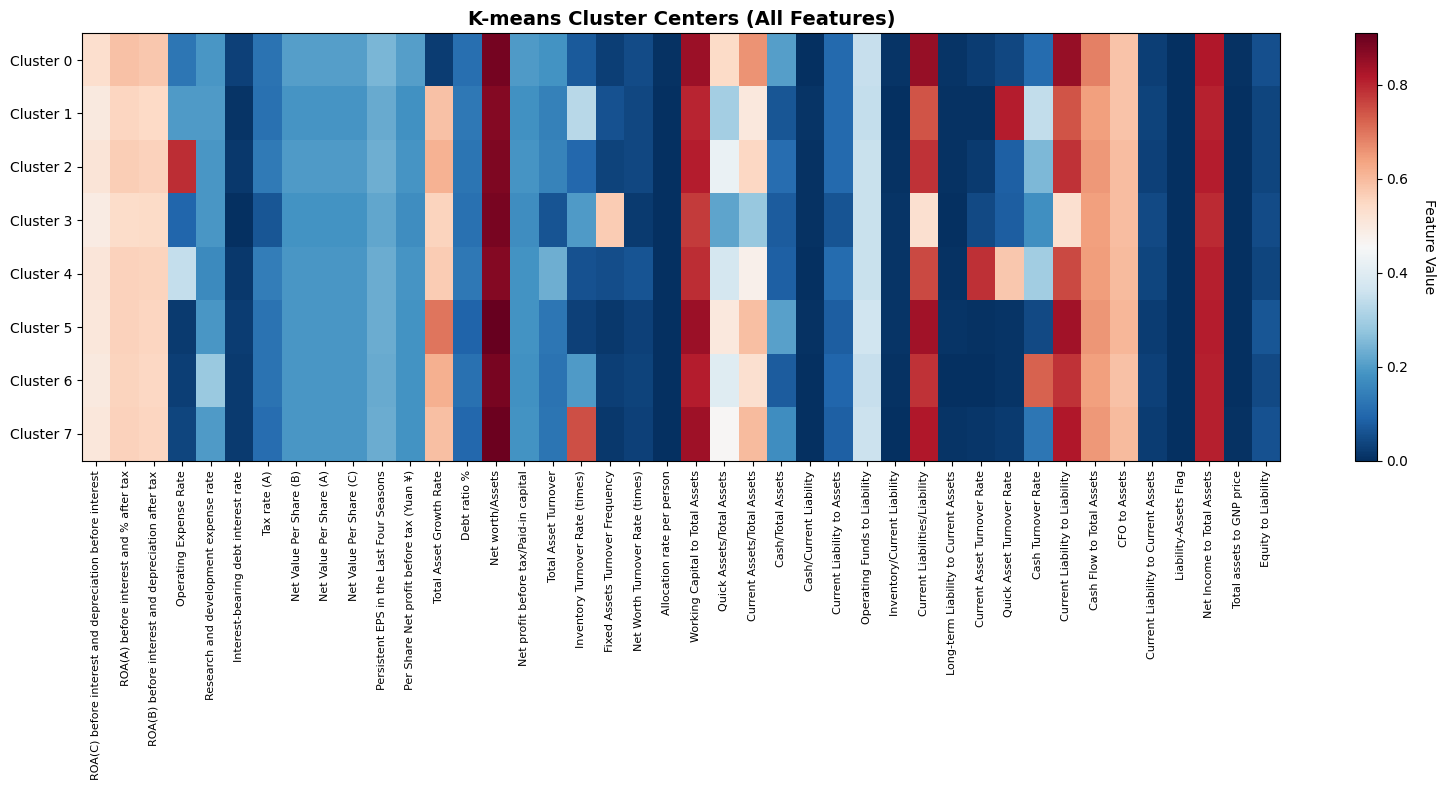


Feature Variance Across Clusters (identifying discriminative features)

Top 10 Features with Highest Variance Across Clusters:
(These features are most important for distinguishing clusters)

 1. Quick Asset Turnover Rate                Variance: 0.084537
 2. Current Asset Turnover Rate              Variance: 0.065051
 3. Operating Expense Rate                   Variance: 0.059252
 4. Inventory Turnover Rate (times)          Variance: 0.048738
 5. Cash Turnover Rate                       Variance: 0.039816
 6. Total Asset Growth Rate                  Variance: 0.038554
 7. Fixed Assets Turnover Frequency          Variance: 0.031689
 8. Current Assets/Total Assets              Variance: 0.011329
 9. Quick Assets/Total Assets                Variance: 0.009884
10. Current Liabilities/Liability            Variance: 0.009122


In [61]:
# Cluster Characteristics Analysis
print(f"{'='*80}")
print("CLUSTER CHARACTERISTICS ANALYSIS")
print(f"{'='*80}\n")

# Get cluster centers
cluster_centers = final_kmeans.cluster_centers_
feature_names = attributes.columns.tolist()

# Create a dataframe of cluster centers for easier analysis
centers_df = pd.DataFrame(cluster_centers, columns=feature_names)

# For each cluster, identify the most distinctive features
print("Top 5 Most Distinctive Features Per Cluster (highest absolute deviation from global mean):\n")

global_mean = attributes.values.mean(axis=0)

for cluster_id in range(optimal_k):
    print(f"{'='*80}")
    print(f"CLUSTER {cluster_id} - {len(clustering_results[clustering_results['Cluster'] == cluster_id])} samples (Bankruptcy rate: {stats_df[stats_df['Cluster'] == cluster_id]['Bankrupt %'].values[0]})")
    print(f"{'='*80}")
    
    # Calculate deviation from global mean for this cluster
    cluster_center = cluster_centers[cluster_id]
    deviations = np.abs(cluster_center - global_mean)
    
    # Get top 5 features with largest deviations
    top_5_idx = np.argsort(deviations)[::-1][:5]
    
    print("\nMost Distinctive Features:")
    for rank, feat_idx in enumerate(top_5_idx, 1):
        feat_name = feature_names[feat_idx]
        cluster_val = cluster_center[feat_idx]
        global_val = global_mean[feat_idx]
        deviation = deviations[feat_idx]
        direction = "HIGHER" if cluster_val > global_val else "LOWER"
        
        print(f"  {rank}. {feat_name}")
        print(f"     Cluster value: {cluster_val:.4f} | Global mean: {global_val:.4f}")
        print(f"     {direction} by {deviation:.4f}\n")

# Create a heatmap of cluster centers
print(f"\n{'='*80}")
print("Cluster Center Heatmap (All Features)")
print(f"{'='*80}\n")

fig, ax = plt.subplots(figsize=(16, 8))
im = ax.imshow(cluster_centers, cmap='RdBu_r', aspect='auto')

# Set ticks and labels
ax.set_xticks(np.arange(len(feature_names)))
ax.set_yticks(np.arange(optimal_k))
ax.set_xticklabels(feature_names, rotation=90, fontsize=8)
ax.set_yticklabels([f'Cluster {i}' for i in range(optimal_k)], fontsize=10)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Feature Value', rotation=270, labelpad=20)

ax.set_title('K-means Cluster Centers (All Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Statistical Summary by Cluster
print(f"\n{'='*80}")
print("Feature Variance Across Clusters (identifying discriminative features)")
print(f"{'='*80}\n")

# Calculate which features have high variance across clusters
feature_variances = []
for feat_idx in range(len(feature_names)):
    cluster_vals = cluster_centers[:, feat_idx]
    variance = np.var(cluster_vals)
    feature_variances.append((feature_names[feat_idx], variance))

# Sort by variance (descending)
feature_variances.sort(key=lambda x: x[1], reverse=True)

print("Top 10 Features with Highest Variance Across Clusters:")
print("(These features are most important for distinguishing clusters)\n")
for rank, (feat_name, variance) in enumerate(feature_variances[:10], 1):
    print(f"{rank:2d}. {feat_name:<40s} Variance: {variance:.6f}")


# Save each clusters to distinc CSV files

In [66]:
# Create comprehensive dataframe with all information
data_with_clusters = attributes.copy()
data_with_clusters['Cluster_ID'] = cluster_labels
data_with_clusters['Bankrupt?'] = train_df_processed['Bankrupt?'].values

print(f"{'='*80}")
print("SAVING CLUSTERS TO CSV FILES")
print(f"{'='*80}\n")

# Create output directory if it doesn't exist
output_dir = '../data/clusters'
import os
os.makedirs(output_dir, exist_ok=True)
print(f"Output directory: {output_dir}\n")

# Save each cluster to a separate CSV file
for cluster_id in range(optimal_k):
    cluster_data = data_with_clusters[data_with_clusters['Cluster_ID'] == cluster_id]
    
    # Generate filename
    filename = f"{output_dir}/cluster_{cluster_id}.csv"
    
    # Save to CSV
    cluster_data.to_csv(filename, index=False)
    
    # Print summary
    num_samples = len(cluster_data)
    num_bankrupt = (cluster_data['Bankrupt?'] == 1).sum()
    bankruptcy_rate = (num_bankrupt / num_samples) * 100
    
    print(f"✓ Cluster {cluster_id}: {filename}")
    print(f"  Samples: {num_samples} | Bankrupt: {num_bankrupt} ({bankruptcy_rate:.2f}%)")

print(f"\n{'='*80}")
print("SUMMARY")
print(f"{'='*80}\n")
print(f"Total clusters saved: {optimal_k}")
print(f"Total samples across all clusters: {len(data_with_clusters)}")
print(f"Each CSV file contains:")
print(f"  - {len(feature_names)} feature columns")
print(f"  - 1 'Cluster_ID' column (cluster membership)")
print(f"  - 1 'Bankrupt?' column (target label)")
print(f"  - Total: {len(feature_names) + 2} columns per file")


SAVING CLUSTERS TO CSV FILES

Output directory: ../data/clusters

✓ Cluster 0: ../data/clusters/cluster_0.csv
  Samples: 571 | Bankrupt: 13 (2.28%)
✓ Cluster 1: ../data/clusters/cluster_1.csv
  Samples: 788 | Bankrupt: 32 (4.06%)
✓ Cluster 2: ../data/clusters/cluster_2.csv
  Samples: 680 | Bankrupt: 23 (3.38%)
✓ Cluster 3: ../data/clusters/cluster_3.csv
  Samples: 742 | Bankrupt: 48 (6.47%)
✓ Cluster 4: ../data/clusters/cluster_4.csv
  Samples: 772 | Bankrupt: 29 (3.76%)
✓ Cluster 5: ../data/clusters/cluster_5.csv
  Samples: 929 | Bankrupt: 24 (2.58%)
✓ Cluster 6: ../data/clusters/cluster_6.csv
  Samples: 627 | Bankrupt: 13 (2.07%)
✓ Cluster 7: ../data/clusters/cluster_7.csv
  Samples: 698 | Bankrupt: 16 (2.29%)

SUMMARY

Total clusters saved: 8
Total samples across all clusters: 5807
Each CSV file contains:
  - 42 feature columns
  - 1 'Cluster_ID' column (cluster membership)
  - 1 'Bankrupt?' column (target label)
  - Total: 44 columns per file


# Classification model to predict cluster label

LOGISTIC REGRESSION CLASSIFIER FOR CLUSTER PREDICTION

Dataset shape: (5807, 42)
Number of clusters to predict: 8
Cluster distribution: [571 788 680 742 772 929 627 698]

Training set size: 4645 samples (80.0%)
Test set size: 1162 samples (20.0%)

Training Logistic Regression classifier...
✓ Training completed

CLASSIFICATION ACCURACY

Training Accuracy: 0.9836 (98.36%)
Test Accuracy:     0.9768 (97.68%)
Difference:        0.0069 (0.69%)

✓ Good generalization: minimal gap between train and test accuracy

DETAILED CLASSIFICATION REPORT (Test Set)

              precision    recall  f1-score   support

   Cluster 0       1.00      0.97      0.99       114
   Cluster 1       0.96      1.00      0.98       158
   Cluster 2       0.97      0.97      0.97       136
   Cluster 3       0.98      0.96      0.97       148
   Cluster 4       0.96      0.99      0.98       155
   Cluster 5       0.98      0.97      0.98       186
   Cluster 6       0.98      0.96      0.97       125
   Cluster 7 

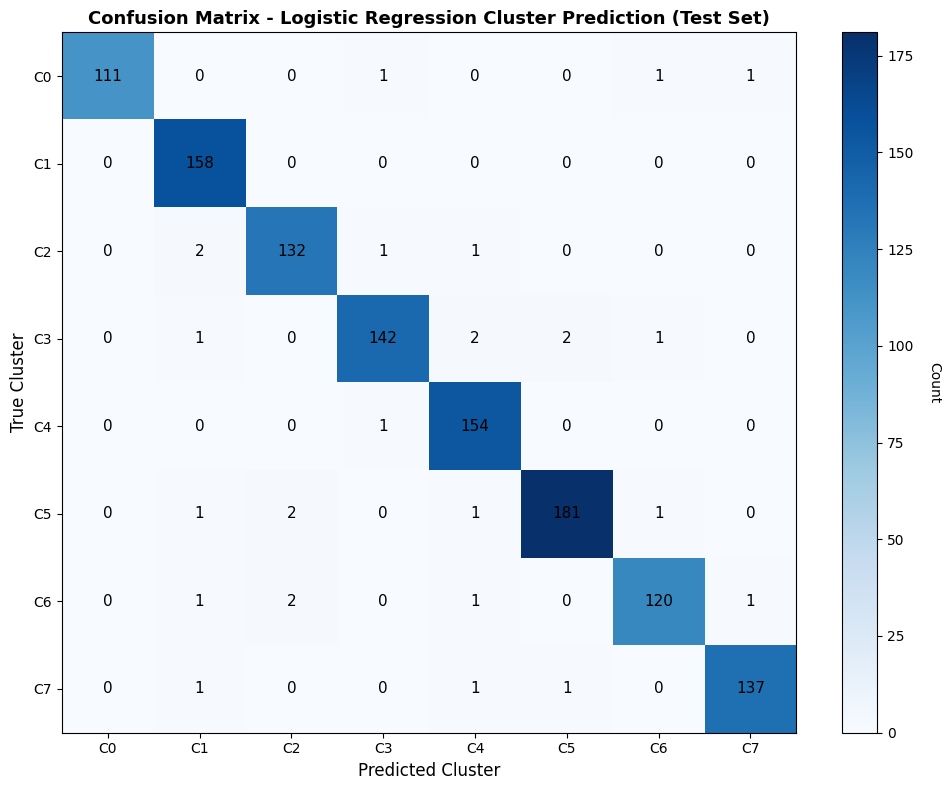

In [65]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

print(f"{'='*80}")
print("LOGISTIC REGRESSION CLASSIFIER FOR CLUSTER PREDICTION")
print(f"{'='*80}\n")

# Prepare data
X = attributes.values  # Features
y = cluster_labels     # Target: cluster labels from K-means

print(f"Dataset shape: {X.shape}")
print(f"Number of clusters to predict: {len(np.unique(y))}")
print(f"Cluster distribution: {np.bincount(y)}\n")

# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=RANDOM_SEED, 
    stratify=y  # Ensure equal distribution across clusters
)

print(f"Training set size: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test set size: {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)\n")

# Train Logistic Regression classifier
print("Training Logistic Regression classifier...")
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_SEED,
    n_jobs=-1
)
log_reg.fit(X_train, y_train)
print("✓ Training completed\n")

# Predictions
y_train_pred = log_reg.predict(X_train)
y_test_pred = log_reg.predict(X_test)

# Accuracy scores
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"{'='*80}")
print("CLASSIFICATION ACCURACY")
print(f"{'='*80}\n")
print(f"Training Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Test Accuracy:     {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Difference:        {(train_accuracy - test_accuracy):.4f} ({(train_accuracy - test_accuracy)*100:.2f}%)")

if train_accuracy - test_accuracy > 0.1:
    print("\n⚠ Note: Large gap between train and test accuracy may indicate overfitting")
else:
    print("\n✓ Good generalization: minimal gap between train and test accuracy")

# Detailed classification report
print(f"\n{'='*80}")
print("DETAILED CLASSIFICATION REPORT (Test Set)")
print(f"{'='*80}\n")
print(classification_report(y_test, y_test_pred, 
                          target_names=[f'Cluster {i}' for i in range(optimal_k)]))

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap='Blues', aspect='auto')

# Set ticks and labels
ax.set_xticks(np.arange(optimal_k))
ax.set_yticks(np.arange(optimal_k))
ax.set_xticklabels([f'C{i}' for i in range(optimal_k)])
ax.set_yticklabels([f'C{i}' for i in range(optimal_k)])

# Add text annotations
for i in range(optimal_k):
    for j in range(optimal_k):
        text = ax.text(j, i, cm[i, j], ha="center", va="center", color="black", fontsize=11)

ax.set_xlabel('Predicted Cluster', fontsize=12)
ax.set_ylabel('True Cluster', fontsize=12)
ax.set_title('Confusion Matrix - Logistic Regression Cluster Prediction (Test Set)', 
             fontsize=13, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Count', rotation=270, labelpad=20)

plt.tight_layout()
plt.show()

## Findings

- The logistic regression classifier achieves 97.68% accuracy on the test set
- This means the cluster characteristics are well-captured by the features
- The model can effectively distinguish between the 8 clusters
- Model is suitable for predicting cluster membership for new companies